In [2]:
%matplotlib inline
from sklearn import datasets
from sklearn.model_selection import train_test_split,GridSearchCV#自動調參
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm



import os,sys
sys.path.append(os.path.abspath('./')) #for import common.utility
# from utility import plot_confusion_matrix,plot_decision_regions,testcase_report

In [15]:
#資料導入
weather_data = pd.read_csv(r'C:\Users\Chen-Wei\pytest\AI_project\taipei_weather.csv')
# print(weather_data)
weather_data = weather_data.drop(['VS01'],axis=1)
weather_data.dropna(inplace=True)
print(weather_data.head())
raining_labels = np.where(weather_data["PP02"] > 0.1, 1, 0)
print(raining_labels.shape)

     stno  yyyymmddhh    PS01    PS02  TX01  RH01  VP01  WD01   WD02  PP01  \
0  466920  2000010101  1015.7  1016.5  19.1  78.0  17.2   2.6   70.0   0.0   
1  466920  2000010102  1015.3  1016.1  18.7  74.0  16.0   0.5  130.0   0.0   
2  466920  2000010103  1015.3  1016.1  18.7  69.0  14.9   2.4  160.0   0.0   
3  466920  2000010104  1015.4  1016.2  18.3  70.0  14.7   0.9  190.0   0.0   
4  466920  2000010105  1016.0  1016.8  17.9  75.0  15.5   0.2    0.0   0.0   

   PP02  SS01  GR01  
0   0.0   0.0   0.0  
1   0.0   0.0   0.0  
2   0.0   0.0   0.0  
3   0.0   0.0   0.0  
4   0.0   0.0   0.0  
(178949,)


In [68]:
#資料預處理
work_data = weather_data.drop(['stno','yyyymmddhh','PP01','PP02'],axis=1)
print(work_data.head(5))
X_train, X_test, y_train, y_test = train_test_split(work_data, raining_labels, test_size=0.3)
print(X_train)


     PS01    PS02  TX01  RH01  VP01  WD01   WD02  SS01  GR01
0  1015.7  1016.5  19.1  78.0  17.2   2.6   70.0   0.0   0.0
1  1015.3  1016.1  18.7  74.0  16.0   0.5  130.0   0.0   0.0
2  1015.3  1016.1  18.7  69.0  14.9   2.4  160.0   0.0   0.0
3  1015.4  1016.2  18.3  70.0  14.7   0.9  190.0   0.0   0.0
4  1016.0  1016.8  17.9  75.0  15.5   0.2    0.0   0.0   0.0
          PS01    PS02  TX01  RH01  VP01  WD01   WD02  SS01  GR01
37972   1008.7  1009.5  22.6  82.0  22.5   1.4  160.0   0.0  0.00
82538   1005.8  1006.5  24.6  57.0  17.7   1.6  150.0   0.0  0.00
88080   1024.9  1025.7  16.6  72.0  13.6   3.5   80.0   0.0  0.00
186335  1016.7  1020.3  17.4  67.0  13.3   3.0  120.0   0.0  0.00
136222   998.3  1001.7  29.8  69.0  28.8   2.1  110.0   0.0  0.00
...        ...     ...   ...   ...   ...   ...    ...   ...   ...
76806   1010.1  1010.8  25.4  77.0  25.0   0.7  150.0   0.5  0.27
83437   1006.0  1006.7  33.9  58.0  30.9   1.1  320.0   0.9  2.32
39418    998.2   998.9  32.9  60.0  29.8

10
[0.09610604 0.1089364  0.11591274 0.35429927 0.09095848 0.08773172
 0.07649374 0.02525014 0.04431146]
[7 8 6 5 4 0 1 2 3]
Index(['SS01', 'GR01', 'WD02', 'WD01', 'VP01', 'PS01', 'PS02', 'TX01', 'RH01'], dtype='object')


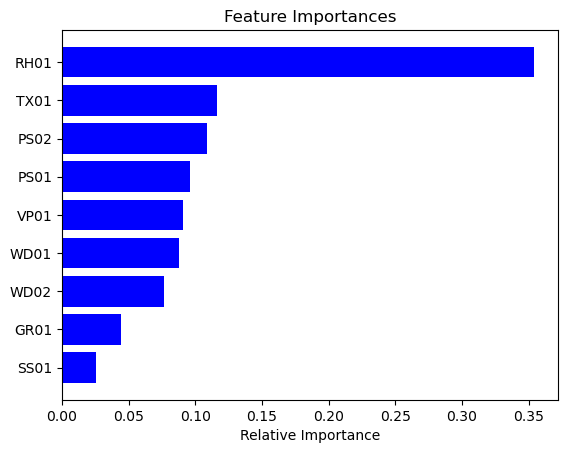

training score: 0.9932063481926172
test score: 0.9232001490174164
30
[0.10017515 0.1027937  0.11126067 0.35250739 0.0904132  0.08894406
 0.07710387 0.03173427 0.04506769]
[7 8 6 5 4 0 1 2 3]
Index(['SS01', 'GR01', 'WD02', 'WD01', 'VP01', 'PS01', 'PS02', 'TX01', 'RH01'], dtype='object')


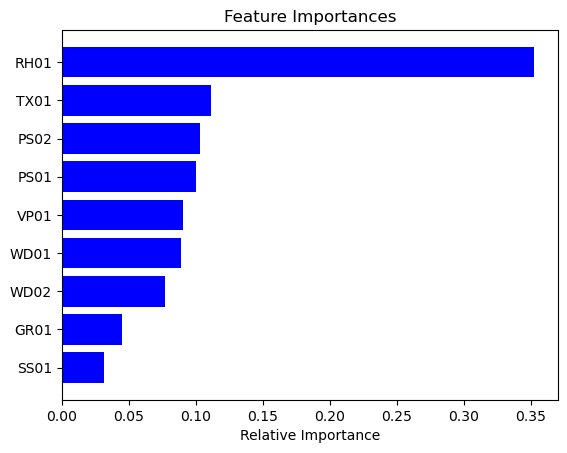

training score: 0.9990579895261208
test score: 0.9262177516997299
50
[0.10205504 0.10382799 0.11419192 0.34193123 0.09186461 0.08789696
 0.07810831 0.03591191 0.04421202]
[7 8 6 5 4 0 1 2 3]
Index(['SS01', 'GR01', 'WD02', 'WD01', 'VP01', 'PS01', 'PS02', 'TX01', 'RH01'], dtype='object')


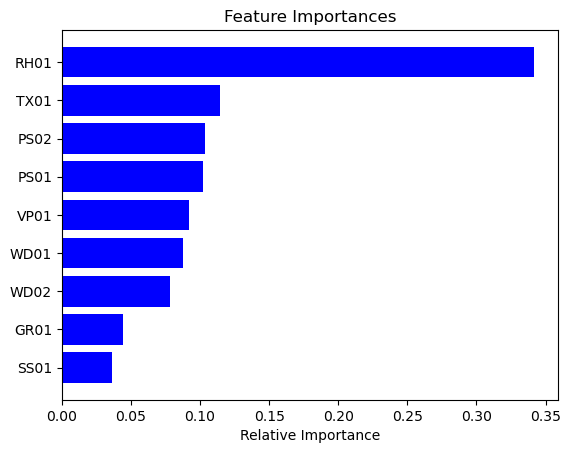

training score: 0.9997205901136799
test score: 0.9276334171556301


In [69]:
#隨機森林測試
tree_number = [10,30,50]
for i in tree_number:
    print(i)
    forest_test = RandomForestClassifier(criterion='entropy', n_estimators=i,n_jobs=8)
    forest_test.fit(X_train,y_train)
    importances = forest_test.feature_importances_#現在特徵的重要性
    print(importances)
    indices = np.argsort(importances)  #np.argsort :Returns the indices that would sort an array. 
    print(indices)#排序索引(最小開始編號)
    feature = X_train.columns
    plt.figure(1)
    print(feature[indices])
    plt.title('Feature Importances')
    plt.barh(range(len(indices)), importances[indices], color='b', align='center')
    plt.yticks(range(len(indices)), feature[indices])
    plt.xlabel('Relative Importance')
    plt.show()
    print('training score:',forest_test.score(X_train,y_train))
    print('test score:',forest_test.score(X_test,y_test))

In [39]:
#進行隨機森林調參
for j in tqdm(range(10)):
    DV = DictVectorizer(sparse=False)
    # print(X_train)
    X_trainDV = DV.fit_transform(X_train.to_dict(orient="records"))
    X_testDV = DV.transform(X_test.to_dict(orient="records"))
    # 實例化隨機森林分類器
    RF = RandomForestClassifier(verbose=0)#verbose=True #verbose=0, callbacks=[TQDMCallback()]
        
    # 測試超參數優化
    RF_param = {"n_estimators":[10,100,300,500],"max_depth":[2,3,4,5]}
        
    print(type(GridSearchCV(RF,param_grid=RF_param,cv=5)))
    GSCV = GridSearchCV(RF,param_grid=RF_param,cv=5)
    GSCV.fit(X_train,y_train)
        
    print("accuracy score",GSCV.score(X_test,y_test))
    print("The best model param :",GSCV.best_params_)

  0%|                                                                                           | 0/10 [00:00<?, ?it/s]

          PS01    PS02  TX01  RH01  VP01  WD01   WD02  SS01  GR01
125828  1010.6  1011.4  24.1  84.0  25.2   1.2   60.0   0.0  0.00
183735  1016.9  1020.5  17.5  83.0  16.5   4.1   80.0   0.0  0.53
8592    1019.8  1020.6  18.3  60.0  12.7   4.4  100.0   0.0  0.00
34878   1018.8  1019.6  15.6  91.0  16.2   0.1    0.0   0.0  0.00
25163   1008.3  1009.0  28.0  61.0  22.9   2.0  280.0   1.0  2.25
...        ...     ...   ...   ...   ...   ...    ...   ...   ...
164225  1005.2  1008.7  27.8  62.0  23.2   2.9   70.0   0.0  0.00
190540  1006.8  1010.3  27.0  87.0  31.1   2.7   90.0   0.0  0.00
127450  1007.7  1008.4  33.1  59.0  29.7   2.6  120.0   0.8  2.76
187123  1007.6  1011.1  28.8  72.0  28.6   1.2   90.0   0.0  0.00
46241   1014.6  1015.4  18.8  82.0  17.7   5.7   70.0   0.0  0.00

[125264 rows x 9 columns]
<class 'sklearn.model_selection._search.GridSearchCV'>


 10%|████████                                                                        | 1/10 [15:19<2:17:56, 919.61s/it]

accuracy score 0.908000372543541
The best model param : {'max_depth': 5, 'n_estimators': 300}
          PS01    PS02  TX01  RH01  VP01  WD01   WD02  SS01  GR01
125828  1010.6  1011.4  24.1  84.0  25.2   1.2   60.0   0.0  0.00
183735  1016.9  1020.5  17.5  83.0  16.5   4.1   80.0   0.0  0.53
8592    1019.8  1020.6  18.3  60.0  12.7   4.4  100.0   0.0  0.00
34878   1018.8  1019.6  15.6  91.0  16.2   0.1    0.0   0.0  0.00
25163   1008.3  1009.0  28.0  61.0  22.9   2.0  280.0   1.0  2.25
...        ...     ...   ...   ...   ...   ...    ...   ...   ...
164225  1005.2  1008.7  27.8  62.0  23.2   2.9   70.0   0.0  0.00
190540  1006.8  1010.3  27.0  87.0  31.1   2.7   90.0   0.0  0.00
127450  1007.7  1008.4  33.1  59.0  29.7   2.6  120.0   0.8  2.76
187123  1007.6  1011.1  28.8  72.0  28.6   1.2   90.0   0.0  0.00
46241   1014.6  1015.4  18.8  82.0  17.7   5.7   70.0   0.0  0.00

[125264 rows x 9 columns]
<class 'sklearn.model_selection._search.GridSearchCV'>


 20%|████████████████                                                                | 2/10 [30:27<2:01:41, 912.74s/it]

...

accuracy score 0.9090248672813636
The best model param : {'max_depth': 5, 'n_estimators': 500}
          PS01    PS02  TX01  RH01  VP01  WD01   WD02  SS01  GR01
125828  1010.6  1011.4  24.1  84.0  25.2   1.2   60.0   0.0  0.00
183735  1016.9  1020.5  17.5  83.0  16.5   4.1   80.0   0.0  0.53
8592    1019.8  1020.6  18.3  60.0  12.7   4.4  100.0   0.0  0.00
34878   1018.8  1019.6  15.6  91.0  16.2   0.1    0.0   0.0  0.00
25163   1008.3  1009.0  28.0  61.0  22.9   2.0  280.0   1.0  2.25
...        ...     ...   ...   ...   ...   ...    ...   ...   ...
164225  1005.2  1008.7  27.8  62.0  23.2   2.9   70.0   0.0  0.00
190540  1006.8  1010.3  27.0  87.0  31.1   2.7   90.0   0.0  0.00
127450  1007.7  1008.4  33.1  59.0  29.7   2.6  120.0   0.8  2.76
187123  1007.6  1011.1  28.8  72.0  28.6   1.2   90.0   0.0  0.00
46241   1014.6  1015.4  18.8  82.0  17.7   5.7   70.0   0.0  0.00

[125264 rows x 9 columns]
<class 'sklearn.model_selection._search.GridSearchCV'>


 90%|████████████████████████████████████████████████████████████████████████        | 9/10 [2:14:41<14:52, 892.71s/it]

accuracy score 0.9087640868026451
The best model param : {'max_depth': 5, 'n_estimators': 100}
          PS01    PS02  TX01  RH01  VP01  WD01   WD02  SS01  GR01
125828  1010.6  1011.4  24.1  84.0  25.2   1.2   60.0   0.0  0.00
183735  1016.9  1020.5  17.5  83.0  16.5   4.1   80.0   0.0  0.53
8592    1019.8  1020.6  18.3  60.0  12.7   4.4  100.0   0.0  0.00
34878   1018.8  1019.6  15.6  91.0  16.2   0.1    0.0   0.0  0.00
25163   1008.3  1009.0  28.0  61.0  22.9   2.0  280.0   1.0  2.25
...        ...     ...   ...   ...   ...   ...    ...   ...   ...
164225  1005.2  1008.7  27.8  62.0  23.2   2.9   70.0   0.0  0.00
190540  1006.8  1010.3  27.0  87.0  31.1   2.7   90.0   0.0  0.00
127450  1007.7  1008.4  33.1  59.0  29.7   2.6  120.0   0.8  2.76
187123  1007.6  1011.1  28.8  72.0  28.6   1.2   90.0   0.0  0.00
46241   1014.6  1015.4  18.8  82.0  17.7   5.7   70.0   0.0  0.00

[125264 rows x 9 columns]
<class 'sklearn.model_selection._search.GridSearchCV'>


100%|███████████████████████████████████████████████████████████████████████████████| 10/10 [2:29:14<00:00, 895.41s/it]

accuracy score 0.910347396852007
The best model param : {'max_depth': 5, 'n_estimators': 100}


In [71]:
#測試隨機森林調參結果
forest_best = RandomForestClassifier(criterion='entropy', n_estimators=100,max_depth=5)
for i in range(10):
    forest_best.fit(X_train,y_train)
    print('training score:',forest_best.score(X_train,y_train))
    print('test score:',forest_best.score(X_test,y_test))
    Y_test_pre = forest_best.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, Y_test_pre))
    # 混淆矩陣
    print("Confusion Matrix:\n", confusion_matrix(y_test, Y_test_pre))
    # 更多指標：Precision、Recall、F1-score
    print("Classification Report:\n", classification_report(y_test, Y_test_pre))

training score: 0.9058468514497382
test score: 0.9040514110086616
Accuracy: 0.9040514110086616
Confusion Matrix:
 [[46927   371]
 [ 4780  1607]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95     47298
           1       0.81      0.25      0.38      6387

    accuracy                           0.90     53685
   macro avg       0.86      0.62      0.67     53685
weighted avg       0.90      0.90      0.88     53685

training score: 0.9073396985566483
test score: 0.9058396200055882
Accuracy: 0.9058396200055882
Confusion Matrix:
 [[46916   382]
 [ 4673  1714]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95     47298
           1       0.82      0.27      0.40      6387

    accuracy                           0.91     53685
   macro avg       0.86      0.63      0.68     53685
weighted avg       0.90      0.91      0.88     53685

training

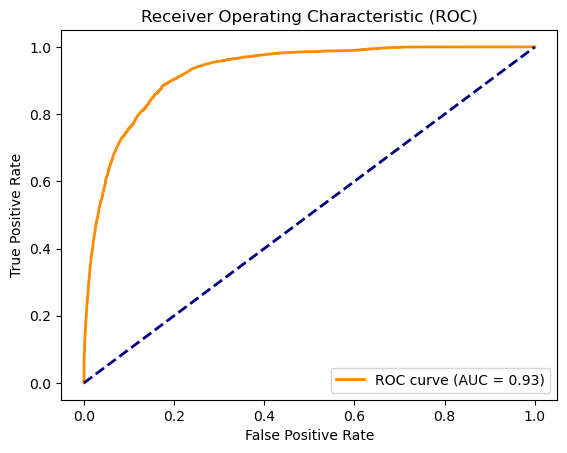

In [72]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=forest_best.classes_)
y_score = forest_best.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()
